<a href="https://www.kaggle.com/code/soumyajitworkspace/notebook62248d3462?scriptVersionId=289698130" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

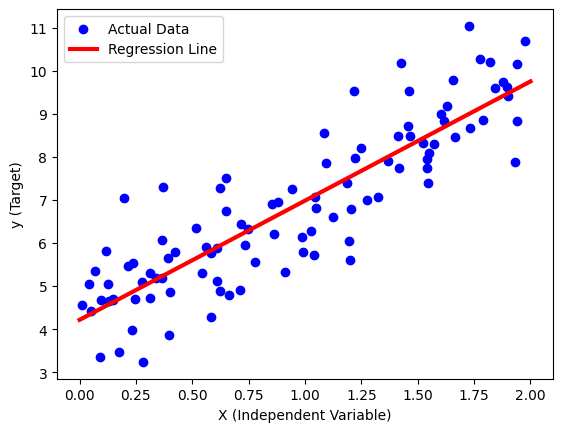

Intercept: 4.215096157546747
Coefficient: 2.7701133864384837


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Generate random data
np.random.seed(42)
X = 2 * np.random.rand(100, 1)  # 100 random points between 0 and 2
# Create y with a linear relationship + some random noise
y = 4 + 3 * X + np.random.randn(100, 1) 

# 2. Initialize and train the model
model = LinearRegression()
model.fit(X, y)

# 3. Make predictions
X_new = np.array([[0], [2]])
y_predict = model.predict(X_new)

# 4. Visualize the results
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X_new, y_predict, color='red', linewidth=3, label='Regression Line')
plt.xlabel('X (Independent Variable)')
plt.ylabel('y (Target)')
plt.legend()
plt.show()

# 5. Show the calculated parameters
print(f"Intercept: {model.intercept_[0]}")
print(f"Coefficient: {model.coef_[0][0]}")

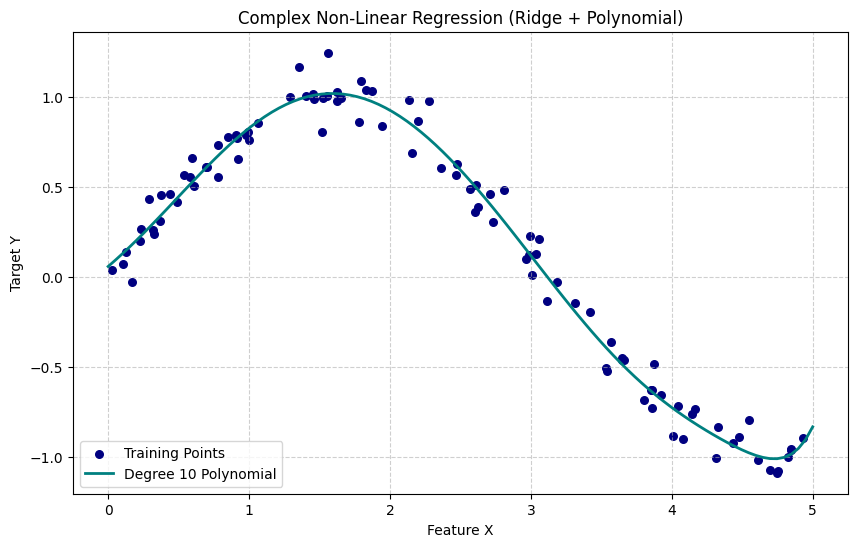

Model Score (R^2): 0.9834


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

# 1. Create complex, non-linear data (Sine wave + Noise)
np.random.seed(42)
X = np.sort(5 * np.random.rand(100, 1), axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])

# 2. Create a "Complex" model
# We use a Pipeline to: 
# a) Generate polynomial features (up to 10th degree)
# b) Apply Ridge regression (Linear regression with L2 regularization)
degree = 10
model = make_pipeline(PolynomialFeatures(degree), Ridge(alpha=0.1))
model.fit(X, y)

# 3. Generate points for a smooth visual curve
X_plot = np.linspace(0, 5, 100)[:, np.newaxis]
y_plot = model.predict(X_plot)

# 4. Visualization
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='navy', s=30, marker='o', label="Training Points")
plt.plot(X_plot, y_plot, color='teal', linewidth=2, label=f"Degree {degree} Polynomial")
plt.title("Complex Non-Linear Regression (Ridge + Polynomial)")
plt.xlabel("Feature X")
plt.ylabel("Target Y")
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 5. Model stats
print(f"Model Score (R^2): {model.score(X, y):.4f}")

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np

# --- 1. The Brain (Neural Network) ---
class Linear_QNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.linear1 = nn.Linear(input_size, hidden_size)
        self.linear2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = torch.relu(self.linear1(x))
        return self.linear2(x)

# --- 2. The Agent (Decision Maker) ---
class Agent:
    def __init__(self):
        self.n_games = 0
        self.epsilon = 0 # randomness
        self.gamma = 0.9 # discount rate
        self.model = Linear_QNet(11, 256, 3) # 11 inputs, 3 outputs (Left, Straight, Right)
        self.optimizer = optim.Adam(self.model.parameters(), lr=0.001)
        self.criterion = nn.MSELoss()

    def get_action(self, state):
        # Exploration vs Exploitation
        self.epsilon = 80 - self.n_games
        if random.randint(0, 200) < self.epsilon:
            move = [0, 0, 0]
            move[random.randint(0, 2)] = 1
            return move
        
        state_tensor = torch.tensor(state, dtype=torch.float)
        prediction = self.model(state_tensor)
        move = [0, 0, 0]
        move[torch.argmax(prediction).item()] = 1
        return move

# Note: You would integrate this Agent into a standard Pygame Snake loop.
# Every frame, you call agent.get_action(current_state) and update the screen.

In [4]:
import pygame
import random
import numpy as np

# --- Hyperparameters ---
ALPHA = 0.1    # Learning rate
GAMMA = 0.9    # Discount factor
EPSILON = 0.1  # Exploration rate

# --- Game Constants ---
WIDTH, HEIGHT = 400, 400
BLOCK_SIZE = 40
FPS = 60

class CatchGame:
    def __init__(self):
        pygame.init()
        self.screen = pygame.display.set_mode((WIDTH, HEIGHT))
        self.clock = pygame.time.Clock()
        self.reset()
        # Q-Table: (relative_x, relative_y) -> 3 actions
        self.q_table = {}

    def reset(self):
        self.paddle_x = WIDTH // 2
        self.ball_x = random.randint(0, WIDTH - BLOCK_SIZE)
        self.ball_y = 0
        return self.get_state()

    def get_state(self):
        # State is the relative distance between ball and paddle
        return (self.ball_x - self.paddle_x, self.ball_y)

    def step(self, action):
        # 0: Left, 1: Stay, 2: Right
        if action == 0 and self.paddle_x > 0:
            self.paddle_x -= 20
        elif action == 2 and self.paddle_x < WIDTH - BLOCK_SIZE:
            self.paddle_x += 20

        self.ball_y += 15
        
        reward = 0
        done = False
        
        # Check collision or miss
        if self.ball_y >= HEIGHT - BLOCK_SIZE:
            if abs(self.paddle_x - self.ball_x) < BLOCK_SIZE:
                reward = 1  # Caught!
            else:
                reward = -1 # Missed!
            done = True
            
        return self.get_state(), reward, done

    def get_action(self, state):
        if random.uniform(0, 1) < EPSILON:
            return random.randint(0, 2) # Explore
        return np.argmax(self.q_table.get(state, [0, 0, 0])) # Exploit

    def train(self, episodes=1000):
        for i in range(episodes):
            state = self.reset()
            done = False
            while not done:
                action = self.get_action(state)
                next_state, reward, done = self.step(action)
                
                # Q-Learning Formula
                old_value = self.q_table.get(state, [0, 0, 0])[action]
                next_max = np.max(self.q_table.get(next_state, [0, 0, 0]))
                
                if state not in self.q_table: self.q_table[state] = [0, 0, 0]
                self.q_table[state][action] = old_value + ALPHA * (reward + GAMMA * next_max - old_value)
                
                state = next_state
                
                # Visuals
                self.screen.fill((0, 0, 0))
                pygame.draw.rect(self.screen, (255, 0, 0), (self.ball_x, self.ball_y, BLOCK_SIZE, BLOCK_SIZE))
                pygame.draw.rect(self.screen, (0, 255, 0), (self.paddle_x, HEIGHT-20, BLOCK_SIZE, 20))
                pygame.display.flip()
                
            if i % 100 == 0: print(f"Episode: {i}")

if __name__ == "__main__":
    game = CatchGame()
    game.train(2000)
    pygame.quit()

pygame 2.6.1 (SDL 2.28.4, Python 3.12.12)
Hello from the pygame community. https://www.pygame.org/contribute.html


error: XDG_RUNTIME_DIR not set in the environment.
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default


Episode: 0
Episode: 100
Episode: 200
Episode: 300
Episode: 400
Episode: 500
Episode: 600
Episode: 700
Episode: 800
Episode: 900
Episode: 1000
Episode: 1100
Episode: 1200
Episode: 1300
Episode: 1400
Episode: 1500
Episode: 1600
Episode: 1700
Episode: 1800
Episode: 1900


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np

# --- 1. The Brain (Neural Network) ---
class Linear_QNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.linear1 = nn.Linear(input_size, hidden_size)
        self.linear2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = torch.relu(self.linear1(x))
        return self.linear2(x)

# --- 2. The Agent (Decision Maker) ---
class Agent:
    def __init__(self):
        self.n_games = 0
        self.epsilon = 0 # randomness
        self.gamma = 0.9 # discount rate
        self.model = Linear_QNet(11, 256, 3) # 11 inputs, 3 outputs (Left, Straight, Right)
        self.optimizer = optim.Adam(self.model.parameters(), lr=0.001)
        self.criterion = nn.MSELoss()

    def get_action(self, state):
        # Exploration vs Exploitation
        self.epsilon = 80 - self.n_games
        if random.randint(0, 200) < self.epsilon:
            move = [0, 0, 0]
            move[random.randint(0, 2)] = 1
            return move
        
        state_tensor = torch.tensor(state, dtype=torch.float)
        prediction = self.model(state_tensor)
        move = [0, 0, 0]
        move[torch.argmax(prediction).item()] = 1
        return move

# Note: You would integrate this Agent into a standard Pygame Snake loop.
# Every frame, you call agent.get_action(current_state) and update the screen.